In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH="/content/drive/MyDrive/SmartRetailAI"

os.listdir(BASE_PATH)

['notebooks', 'datasets', 'models', 'outputs', 'logs']

In [ ]:
!pip install tensorflow
!pip install matplotlib
!pip install opencv-python
!pip install scikit-learn

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

print("Training:", train_images.shape)
print("Testing :", test_images.shape)

Training: (60000, 28, 28)
Testing : (10000, 28, 28)


In [ ]:
print(train_labels[:10])

[9 0 0 3 0 2 7 2 5 5]


In [ ]:
class_names = [
'T-shirt',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

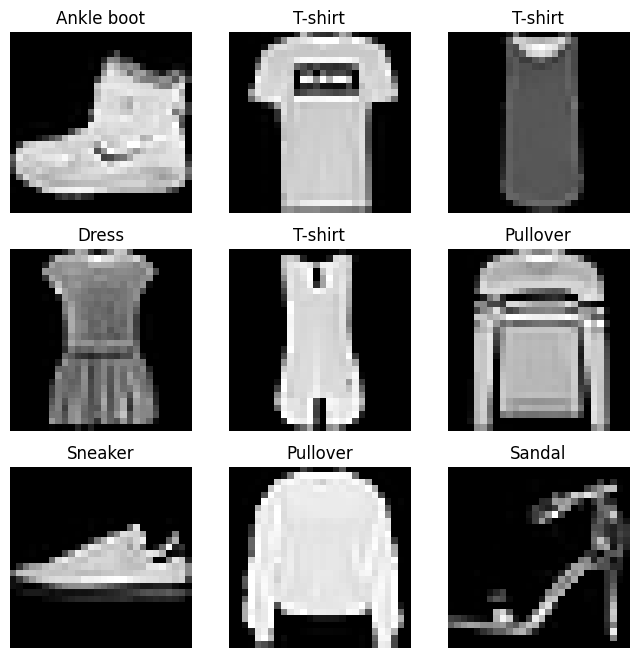

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')

plt.show()

In [ ]:
IMG_SIZE=96
BATCH_SIZE=32

def preprocess(image,label):

    image=tf.expand_dims(image,-1)

    image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))

    image=tf.image.grayscale_to_rgb(image)

    image=tf.cast(image,tf.float32)/255.0

    return image,label

In [ ]:
train_ds=tf.data.Dataset.from_tensor_slices(
    (train_images,train_labels)
)

train_ds=train_ds.map(preprocess)

train_ds=train_ds.batch(BATCH_SIZE)

train_ds=train_ds.prefetch(tf.data.AUTOTUNE)


test_ds=tf.data.Dataset.from_tensor_slices(
    (test_images,test_labels)
)

test_ds=test_ds.map(preprocess)

test_ds=test_ds.batch(BATCH_SIZE)

test_ds=test_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
base_model=MobileNetV2(

    input_shape=(96,96,3),

    include_top=False,

    weights="imagenet"

)

base_model.trainable=False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model=Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(128,activation="relu"),

    Dense(10,activation="softmax")

])

In [ ]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 521s 274ms/step - accuracy: 0.8494 - loss: 0.4155 - val_accuracy: 0.8764 - val_loss: 0.3331
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 560s 273ms/step - accuracy: 0.8798 - loss: 0.3255 - val_accuracy: 0.8829 - val_loss: 0.3149
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 576s 281ms/step - accuracy: 0.8874 - loss: 0.3019 - val_accuracy: 0.8838 - val_loss: 0.3101
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 559s 279ms/step - accuracy: 0.8933 - loss: 0.2820 - val_accuracy: 0.8885 - val_loss: 0.3093
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 523s 279ms/step - accuracy: 0.8967 - loss: 0.2697 - val_accuracy: 0.8911 - val_loss: 0.2977


In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 232ms/step - accuracy: 0.8911 - loss: 0.2977
Test Accuracy: 0.8910999894142151
Test Loss: 0.297657310962677


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/SmartRetailAI/models/product_classifier.h5"

model.save(MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!


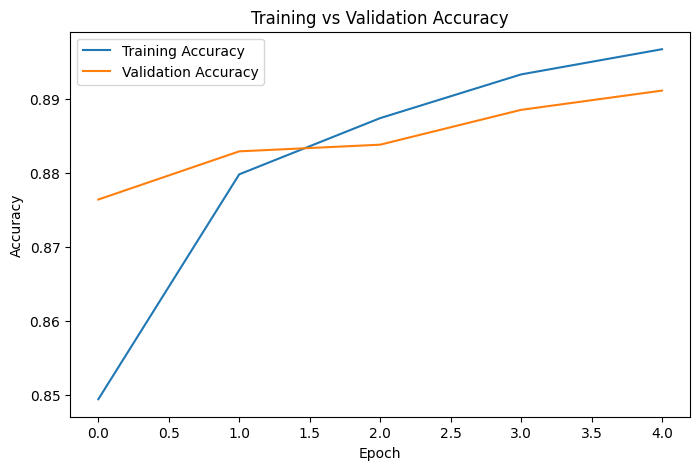

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig("/content/drive/MyDrive/SmartRetailAI/outputs/accuracy.png")
plt.show()

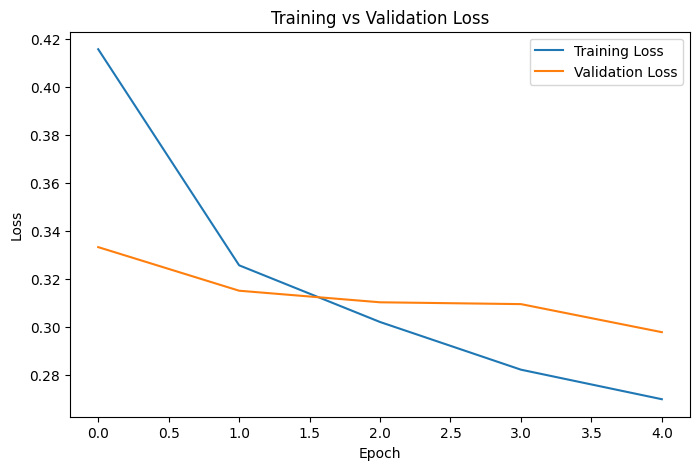

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig("/content/drive/MyDrive/SmartRetailAI/outputs/loss.png")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


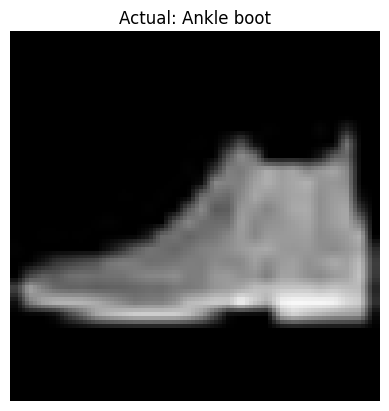

Predicted Category: Ankle boot
Confidence Score: 98.26%


In [ ]:
images, labels = next(iter(test_ds))

prediction = model.predict(images[:1])

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

plt.imshow(images[0])
plt.title(f"Actual: {class_names[labels[0].numpy()]}")
plt.axis("off")
plt.show()

print("Predicted Category:", class_names[predicted_class])
print(f"Confidence Score: {confidence * 100:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [ ]:
cm = confusion_matrix(y_true, y_pred)

<Figure size 1000x1000 with 0 Axes>

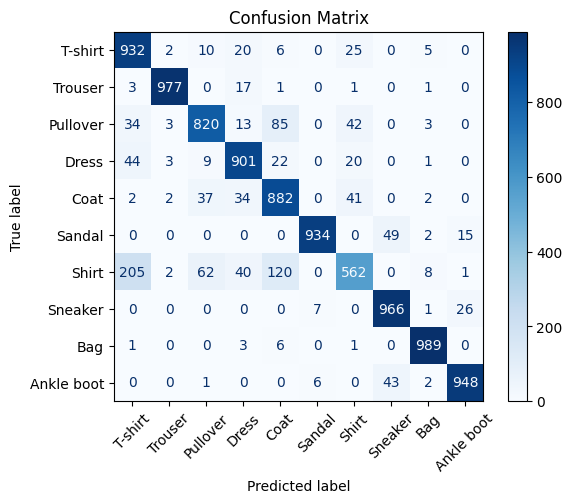

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")

plt.savefig("/content/drive/MyDrive/SmartRetailAI/outputs/confusion_matrix.png")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     T-shirt       0.76      0.93      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.87      0.82      0.85      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.79      0.88      0.83      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.81      0.56      0.66      1000
     Sneaker       0.91      0.97      0.94      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

with open("/content/drive/MyDrive/SmartRetailAI/outputs/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved successfully!")

Classification report saved successfully!


SmartRetailAI: AI-Powered Retail Assistant
Project Report
Submitted By
Krishnam Singh
App No- IN26012720
Reg No- 23BCE10179
B.Tech Computer Science & Engineering
VIT Bhopal University
________________________________________
Table of Contents
1.	Abstract
2.	Introduction
3.	Problem Statement
4.	Objectives
5.	Scope of the Project
6.	Existing System
7.	Proposed System
8.	Technology Stack
9.	Software Requirements
10.	Hardware Requirements
11.	System Architecture
12.	Project Modules
13.	Module 1 – Product Classification
14.	Module 2 – Face Recognition
15.	Module 3 – Sentiment Analysis
16.	Module 4 – AI Chatbot
17.	Backend Development
18.	Frontend Development
19.	Docker Containerization
20.	API Documentation
21.	Folder Structure
22.	Working Methodology
23.	Testing
24.	Results
25.	Future Enhancements
26.	Conclusion
27.	References
________________________________________
Chapter 1 – Abstract
SmartRetailAI is an AI-based retail assistant that integrates multiple machine learning and deep learning models into a single web application. The system helps retailers automate product recognition, customer identification, sentiment analysis of customer reviews, and intelligent customer support using an AI chatbot.
The backend is developed using FastAPI and Python, while the frontend is built using React.js and Bootstrap. TensorFlow is used for image classification, Scikit-learn for sentiment analysis and face recognition, and Natural Language Processing techniques for the chatbot.
The application demonstrates the practical use of Artificial Intelligence in the retail industry by reducing manual effort and improving customer experience.
________________________________________
Chapter 2 – Introduction
The retail industry is rapidly adopting Artificial Intelligence to improve customer experience, automate repetitive tasks, and provide intelligent insights.
Traditional retail systems depend heavily on manual operations, making product identification, customer service, and review analysis time-consuming.
SmartRetailAI addresses these challenges through:
•	Product image classification
•	Customer face recognition
•	Automated review sentiment analysis
•	Intelligent FAQ chatbot
________________________________________
Chapter 3 – Problem Statement
Retail stores often face several operational challenges:
•	Manual product categorization
•	Difficulty identifying returning customers
•	Thousands of customer reviews requiring manual analysis
•	High customer support workload
These issues reduce efficiency and increase operational costs.
________________________________________
Chapter 4 – Objectives
The objectives are:
•	Develop an AI-powered retail assistant.
•	Classify products using deep learning.
•	Recognize customers using facial recognition.
•	Analyze customer sentiment automatically.
•	Build a chatbot for answering common customer queries.
•	Provide REST APIs for all AI services.
•	Design a responsive web interface.
•	Deploy using Docker containers.
________________________________________
Chapter 5 – Scope
The system can be used by:
•	Retail stores
•	Shopping malls
•	Supermarkets
•	E-commerce companies
•	Inventory management systems
•	Customer support systems
Future versions can integrate:
•	Payment systems
•	Barcode scanning
•	Recommendation engines
•	Voice assistants
________________________________________
Chapter 6 – Existing System
Existing systems generally perform only one task:
•	Product recognition software
•	Face recognition software
•	Review analysis software
•	Customer support chatbot
These systems operate independently.
Limitations:
•	Multiple software solutions required
•	High operational costs
•	No centralized platform
•	Limited automation
________________________________________
Chapter 7 – Proposed System
SmartRetailAI combines four AI modules into one platform.
Features include:
•	Product Classification
•	Face Recognition
•	Sentiment Analysis
•	AI Chatbot
Advantages:
•	Single platform
•	Faster processing
•	Easy integration
•	REST APIs
•	Modern web interface
________________________________________
Chapter 8 – Technology Stack
Frontend
•	React.js
•	Vite
•	Bootstrap
•	Axios
•	React Router
•	React Icons
Backend
•	FastAPI
•	Uvicorn
•	Python
Machine Learning
•	TensorFlow
•	Keras
•	Scikit-learn
•	OpenCV
•	NumPy
•	Pandas
Deployment
•	Docker
•	Docker Compose
•	Nginx
________________________________________
Chapter 9 – Software Requirements
Software	Version
Python	3.11
Node.js	20
React	19
FastAPI	Latest
TensorFlow	Latest
Docker	Latest
VS Code	Latest
Git	Latest
________________________________________
Chapter 10 – Hardware Requirements
Minimum:
•	Intel i5 Processor
•	8 GB RAM
•	10 GB Free Storage
Recommended:
•	Intel i7
•	16 GB RAM
•	SSD Storage
•	NVIDIA GPU (Optional)
________________________________________
Chapter 11 – System Architecture
                User

                  │

                  ▼

          React Frontend

                  │

             Axios API Calls

                  │

                  ▼

          FastAPI Backend

      ┌────────┼────────┬────────┐

      ▼        ▼        ▼        ▼

Product   Face     Sentiment  Chatbot

Classifier Recognition Analysis Model

      │

      ▼

Saved Models (.h5/.pkl)
________________________________________
Chapter 12 – Modules
Module 1
Product Classification
Uses TensorFlow CNN model.
Input:
Product image
Output:
Category
Confidence Score
Dataset:
Fashion-MNIST
________________________________________
Module 2
Face Recognition
Uses Olivetti Faces dataset.
Input:
Face image
Output:
Predicted Person ID
Confidence
________________________________________
Module 3
Sentiment Analysis
Uses TF-IDF and Logistic Regression.
Input:
Customer Review
Output:
Positive
Negative
________________________________________
Module 4
AI Chatbot
Uses TF-IDF and Logistic Regression with an intents.json knowledge base.
Input:
User Question
Output:
Best matching response
________________________________________
Chapter 13 – Backend
Developed using FastAPI.
API Endpoints:
Endpoint	Method
/classify-product	POST
/recognize-face	POST
/analyze-review	POST
/chat	POST
Swagger:
http://localhost:8000/docs
________________________________________
Chapter 14 – Frontend
Developed using React.
Features:
•	Sidebar
•	Dashboard
•	Bootstrap Cards
•	Image Preview
•	Loading Spinner
•	Progress Bars
•	Prediction History
•	Chat UI
________________________________________
Chapter 15 – Docker
Backend
Python Container
↓
Frontend
Nginx Container
↓
Docker Compose
One command deployment:
docker compose up
________________________________________
Chapter 16 – Folder Structure
SmartRetailAI/

backend/

app/

routers/

services/

models/

frontend/

src/

components/

pages/

Dockerfile

docker-compose.yml
________________________________________
Chapter 17 – Testing
Product Classification
Input:
Sneaker Image
Output:
Sneaker
98%
________________________________________
Face Recognition
Input:
Face
Output:
Person ID 5
100%
________________________________________
Sentiment Analysis
Input:
Amazing Product
Output:
Positive
________________________________________
Chatbot
Input:
Hi
Output:
Hello! Welcome to SmartRetailAI.
________________________________________
Chapter 18 – Results
The application successfully:
•	Classified product images
•	Recognized faces
•	Predicted review sentiment
•	Answered user queries
•	Exposed REST APIs
•	Connected React and FastAPI
•	Ran successfully in Docker containers
________________________________________
Chapter 19 – Conclusion
SmartRetailAI demonstrates how Artificial Intelligence can be integrated into modern retail systems through a unified web platform. By combining image classification, face recognition, sentiment analysis, and an intelligent chatbot into a single application, the project improves automation, customer engagement, and operational efficiency. The modular architecture built with React, FastAPI, TensorFlow, and Docker makes the system scalable, maintainable, and suitable for further enhancements and real-world deployment.

